# Adult Income Dataset - Machine Learning Pipeline

## Objective

Build an end-to-end machine learning pipeline that:

- Handles missing values
- Encodes categorical variables
- Transforms numerical variables
- Creates engineered features
- Trains a classification model
- Evaluates model performance

## Pipeline Goals

1. Prevent data leakage
2. Automate preprocessing
3. Compare baseline and engineered features
4. Create a reusable workflow

# Dataset Information

Dataset: Adult Income Census Dataset

Problem Type:
- Binary Classification

Target Variable:
- income

Classes:
- <=50K
- .>50K

Objective:
Predict whether an individual's annual income exceeds $50,000 based on demographic, educational and employment information.

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay

In [47]:
df = pd.read_csv("/content/adult.csv")

In [48]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [49]:
df.drop('fnlwgt',axis = 1,inplace = True)

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
X = df.drop('income',axis=1)
le = LabelEncoder()
y = le.fit_transform(df['income'])

In [52]:
y

array([0, 0, 0, ..., 0, 0, 0])

# Train-Test Split

## Objective

Separate training and testing data before preprocessing.

## Why?

Performing preprocessing before splitting can cause data leakage.

The model should only learn patterns from training data.

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42
                                                 )

# Missing Value Handling

## Objective

Convert placeholder missing values into proper NaN values.

## Approach

The Adult Income dataset uses '?' to represent missing information.

These values are converted into NaN so that pipeline-based imputation can be applied.

In [54]:
X_train = X_train.replace('?', np.nan)
X_test = X_test.replace('?', np.nan)

In [55]:
num_cols = X_train.select_dtypes(
    include=['int','float']
).columns.tolist()

In [56]:
cat_cols = X_train.select_dtypes(
    include = ['object']
).columns.tolist()

In [57]:
num_cols

['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

In [58]:
cat_cols

['workclass',
 'education',
 'marital.status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native.country']

# Numerical Pipeline

## Components

### Median Imputation

Handles missing numerical values.

### Power Transformation

Reduces skewness and improves distribution shape.

### Standard Scaling

Standardizes feature magnitudes.

## Benefits

- Handles missing values
- Improves numerical stability
- Helps linear models perform better

In [59]:
num_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('transformer',PowerTransformer(method= 'yeo-johnson')),
    ('scaling',StandardScaler())
])

# Categorical Pipeline

## Components

### Constant Imputation

Missing categories are replaced with 'Unknown'.

### One-Hot Encoding

Converts categorical features into numerical format.

### Handle Unknown Categories

Prevents failures when unseen categories appear during prediction.

## Benefits

- Robust handling of missing values
- Production-safe encoding
- Model compatibility

In [60]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='unknown')),
    ('encoder',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=True))
])

# Column Transformer

The numerical and categorical pipelines are combined into a single preprocessing workflow.

This ensures consistent preprocessing for both training and inference.

In [61]:
preprocessor = ColumnTransformer([
    ('cat_cols',cat_pipeline,cat_cols),
    ('num_cols',num_pipeline,num_cols)
],remainder='drop')

# Baseline Model

## Objective

Train a Logistic Regression model using the original dataset without engineered features.

## Purpose

Establish a performance benchmark that can be compared against the feature-engineered pipeline.

In [62]:
base_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

In [63]:
base_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country']),
                                                 ('num_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   PowerTransformer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('model', LogisticRegression())])

In [64]:
y_pred = base_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Baseline Performance

The baseline model represents performance before introducing engineered features.

This serves as the reference point for evaluating feature engineering effectiveness.

In [65]:
base_acc = accuracy_score(y_test,y_pred)
print(base_acc)

0.8393470790378007


In [66]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4433
           1       0.69      0.59      0.63      1387

    accuracy                           0.84      5820
   macro avg       0.78      0.75      0.77      5820
weighted avg       0.83      0.84      0.83      5820



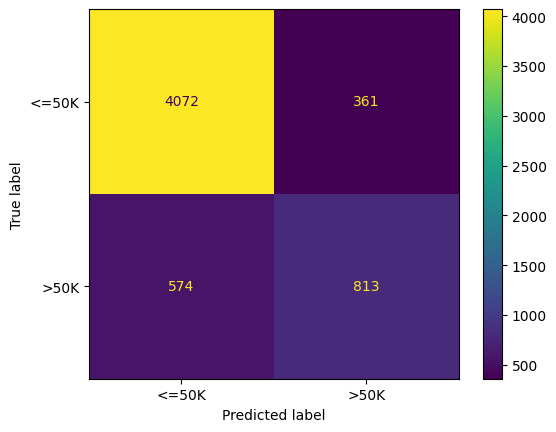

In [67]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)


# **Feature Engineering Experiment**

# Feature Engineering Pipeline

## Objective

Evaluate whether engineered features improve predictive performance.

## Engineered Features

- age_groups
- work_intensity
- education_level
- marital_group
- occupation_group
- family_role
- region

## Expected Benefits

- Reduced cardinality
- Improved business representation
- Better target separation

# Custom Feature Transformer

A custom transformer is used to generate engineered features within the machine learning pipeline.

Benefits:

- Reproducible feature engineering
- Prevents data leakage
- Fully integrated preprocessing workflow

# Feature Engineering Hypothesis

Feature engineering is performed with the assumption that grouped and domain-informed features may provide stronger predictive signals than raw features alone.

The objective is to reduce noise while preserving meaningful information.

In [68]:
class AdultFeatureCreator(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['age_groups'] = pd.cut(
        X['age'],
        bins = [17,25,35,50,60,100],
        labels=[
           'Young Adult',
           'Early Career',
           'Mid Career',
           'Senior Professional',
           'Retired'
          ]
        )

        X['work_intensity'] = pd.cut(
        X['hours.per.week'],
        bins=[0,20,40,60,100],
        labels=[
          'Part Time',
          'Full Time',
          'Overtime',
          'Heavy Overtime'
          ]
         )

        education_map = {
        'Preschool': 'School Education',
        '1st-4th': 'School Education',
        '5th-6th': 'School Education',
        '7th-8th': 'School Education',
        '9th': 'School Education',
        '10th': 'School Education',
        '11th': 'School Education',
        '12th': 'School Education',

        'HS-grad': 'High School Graduate',

        'Some-college': 'Undergraduate',
        'Assoc-acdm': 'Undergraduate',
        'Assoc-voc': 'Undergraduate',

        'Bachelors': 'Graduate',

        'Masters': 'Postgraduate',

        'Prof-school': 'Professional Degree',

        'Doctorate': 'Doctorate'
        }
        X['education_level'] = X['education'].map(education_map)


        marital_map = {
        'Married-civ-spouse': 'Married',
        'Married-AF-spouse': 'Married',
        'Married-spouse-absent': 'Married',

        'Never-married': 'Single',

        'Divorced': 'Previously Married',
        'Separated': 'Previously Married',
        'Widowed': 'Previously Married'
        }

        X['marital_group'] = X['marital.status'].map(marital_map)

        occupation_map = {
          'Exec-managerial': 'White Collar',
          'Prof-specialty': 'White Collar',
          'Adm-clerical': 'White Collar',
          'Sales': 'White Collar',
          'Tech-support': 'White Collar',

          'Craft-repair': 'Skilled Labor',
          'Machine-op-inspct': 'Skilled Labor',
          'Transport-moving': 'Skilled Labor',
          'Farming-fishing': 'Skilled Labor',

          'Handlers-cleaners': 'Blue Collar',

          'Other-service': 'Service',
          'Priv-house-serv': 'Service',

          'Protective-serv': 'Public Service',

          'Armed-Forces': 'Military'
        }

        X['occupation_group'] = X['occupation'].map(occupation_map)


        relationship_map = {
          'Husband': 'Spouse',
          'Wife': 'Spouse',

          'Own-child': 'Child',

          'Other-relative': 'Relative',

          'Unmarried': 'Independent Adult',
          'Not-in-family': 'Independent Adult'
        }

        X['family_role'] = X['relationship'].map(relationship_map)

        region_map = {
          'United-States': 'North America',
          'Canada': 'North America',

          'England': 'Europe',
          'Germany': 'Europe',
          'France': 'Europe',
          'Italy': 'Europe',
          'Ireland': 'Europe',
          'Portugal': 'Europe',
          'Greece': 'Europe',
          'Scotland': 'Europe',

          'India': 'Asia',
          'China': 'Asia',
          'Japan': 'Asia',
          'Iran': 'Asia',
          'Vietnam': 'Asia',
          'Taiwan': 'Asia',
          'Philippines': 'Asia',
          'Hong': 'Asia',
          'Cambodia': 'Asia',
          'Thailand': 'Asia',
          'Laos': 'Asia',

          'Mexico': 'Latin America',
          'Cuba': 'Latin America',
          'Jamaica': 'Latin America',
          'Puerto-Rico': 'Latin America',
          'Dominican-Republic': 'Latin America',
          'Haiti': 'Latin America',
          'Guatemala': 'Latin America',
          'Nicaragua': 'Latin America',
          'El-Salvador': 'Latin America',
          'Honduras': 'Latin America',
          'Columbia': 'Latin America',
          'Ecuador': 'Latin America',
          'Peru': 'Latin America',
          'Trinadad&Tobago': 'Latin America',

          'South': 'Other',
          'Poland': 'Other',
          'Hungary': 'Other',
          'Yugoslavia': 'Other',
          'Holand-Netherlands': 'Other'
        }

        X['region'] = X['native.country'].map(region_map)


        return X

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42
                                                 )

In [70]:
X_train = X_train.replace('?', np.nan)
X_test = X_test.replace('?', np.nan)

In [71]:
cat_cols = X_train.select_dtypes(
    include = ['object']
).columns.tolist()

In [72]:
cat_cols.extend(['family_role','age_groups','work_intensity','education_level','marital_group','occupation_group','region'])

In [73]:
num_cols = X_train.select_dtypes(
    include=['int','float']
).columns.tolist()

In [74]:
cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='unknown')),
    ('encoder',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=True))
])

In [75]:
preprocessor = ColumnTransformer([
    ('cat_cols',cat_pipeline,cat_cols),
    ('num_cols',num_pipeline,num_cols)
],remainder='drop')

In [85]:
feature_pipeline = Pipeline([
    ('feature_creator', AdultFeatureCreator()),
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

In [86]:
feature_pipeline.fit(X_train,y_train)

Pipeline(steps=[('feature_creator', AdultFeatureCreator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('cat_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex'...
                                                   'family_role', 'age_groups',
                                                   'work_intensity',
                                                   'education_level',
                                                   'marital_group',
                                                   'occupation_group',
                                                   'region']),
                                                 ('num_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   PowerTransformer()),
                                                                  ('scaling',
                                                                   StandardScaler())]),
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('model', LogisticRegression())])

In [87]:
y_pred = feature_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


# Model Comparison

## Baseline Accuracy

(base_acc)

## Feature Engineered Accuracy

(feature_acc)

## Evaluation

Compare the impact of engineered features on model performance.

In [88]:
feature_acc = accuracy_score(y_test,y_pred)
feature_acc

0.8365979381443299

In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4433
           1       0.69      0.58      0.63      1387

    accuracy                           0.84      5820
   macro avg       0.78      0.75      0.76      5820
weighted avg       0.83      0.84      0.83      5820



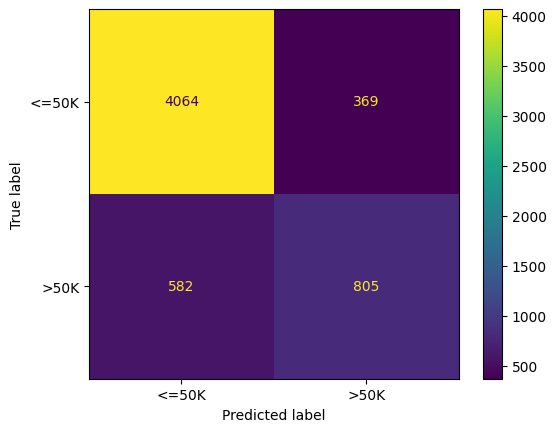

In [81]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)

# Performance Interpretation

Possible outcomes:

### Feature Engineered Model Performs Better

Engineered features successfully captured additional information.

### Similar Performance

Feature engineering neither improved nor degraded model performance significantly.

### Worse Performance

Engineered features may have introduced noise or redundant information.

In [82]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Feature Engineered'],
    'Accuracy': [base_acc, feature_acc]
})

comparison

,Model,Accuracy
0,Baseline,0.839347
1,Feature Engineered,0.836598


## Improvement Analysis

The difference between baseline and engineered performance indicates the contribution of feature engineering.

In [83]:
improvement = feature_acc - base_acc

print(f'Improvement: {improvement:.4f}')

Improvement: -0.0027


In [84]:
print("Original Features:", X.shape[1])

print(
    "Processed Features:",
    len(
        feature_pipeline.named_steps[
            'preprocessor'
        ].get_feature_names_out()
    )
)

Original Features: 13
Processed Features: 128


# Feature Space Expansion

One-Hot Encoding and feature engineering increase the dimensionality of the dataset.

This section compares:

- Original feature count
- Processed feature count

to understand the impact of preprocessing.

# Final Conclusions

## Key Achievements

1. Built a complete machine learning pipeline using sklearn Pipeline and ColumnTransformer.

2. Implemented automated preprocessing for numerical and categorical features.

3. Created custom domain-driven engineered features.

4. Compared baseline and feature-engineered models.

5. Evaluated model performance using classification metrics.

## Feature Engineering Impact

The comparison between baseline and engineered models demonstrates whether newly created features contribute meaningful predictive information.

## Production Readiness

The preprocessing workflow is reusable, reproducible and suitable for deployment in larger machine learning systems.

## Learning Outcomes

- Missing Value Handling
- Feature Engineering
- Pipeline Development
- ColumnTransformer Usage
- Automated Preprocessing
- Model Evaluation